<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Lab%202/%20lab_2_epley_win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install fredapi

In [6]:
!pip install fredapi

import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
fred = Fred(api_key='31dd542f47c1437d259d9d93d20d9f59')

In [7]:
# 1. Fetch the data series
print("Fetching data from FRED...")
wages = fred.get_series('AHETPI')
cpi = fred.get_series('CPIAUCSL')

# 2. Combine into a DataFrame
df = pd.DataFrame({'Nominal_Wage': wages, 'CPI': cpi})

# 3. Drop missing values (The wage data starts later than CPI data)
df = df.dropna()

# Inspect the raw data
print(df.head(10))
print(df.tail(10))

Fetching data from FRED...
            Nominal_Wage    CPI
1964-01-01          2.50  30.94
1964-02-01          2.50  30.91
1964-03-01          2.51  30.94
1964-04-01          2.52  30.95
1964-05-01          2.52  30.98
1964-06-01          2.53  31.01
1964-07-01          2.54  31.02
1964-08-01          2.55  31.05
1964-09-01          2.56  31.08
1964-10-01          2.55  31.12
            Nominal_Wage      CPI
2025-02-01         30.91  319.775
2025-03-01         30.97  319.615
2025-04-01         31.05  320.321
2025-05-01         31.14  320.580
2025-06-01         31.26  321.500
2025-07-01         31.35  322.132
2025-08-01         31.45  323.364
2025-09-01         31.52  324.368
2025-11-01         31.73  325.031
2025-12-01         31.76  326.030


In [11]:
def get_real_wage(nominal_col, cpi_col):
    """
    Takes a nominal column and a CPI column.
    Returns a new column adjusted for inflation (Real Dollars).
    """
    # 1. Get the CPI of the most recent date (Today's Prices)
    # .iloc[-1] grabs the very last row in the data
    cpi_today = cpi_col.iloc[-1]

    # 2. The Formula: (Nominal / Old_CPI) * CPI_Today
    real_col = (nominal_col / cpi_col) * cpi_today

    return real_col

# Apply the function to create a new column
# We feed the "Machine" our two columns:
df['Real_Wage'] = get_real_wage(df['Nominal_Wage'], df['CPI'])

# Check the result - Notice how Real Wages are different from Nominal!
print(df.tail())

            Nominal_Wage      CPI  Real_Wage
2025-07-01         31.35  322.132  31.729355
2025-08-01         31.45  323.364  31.709292
2025-09-01         31.52  324.368  31.681502
2025-11-01         31.73  325.031  31.827524
2025-12-01         31.76  326.030  31.760000


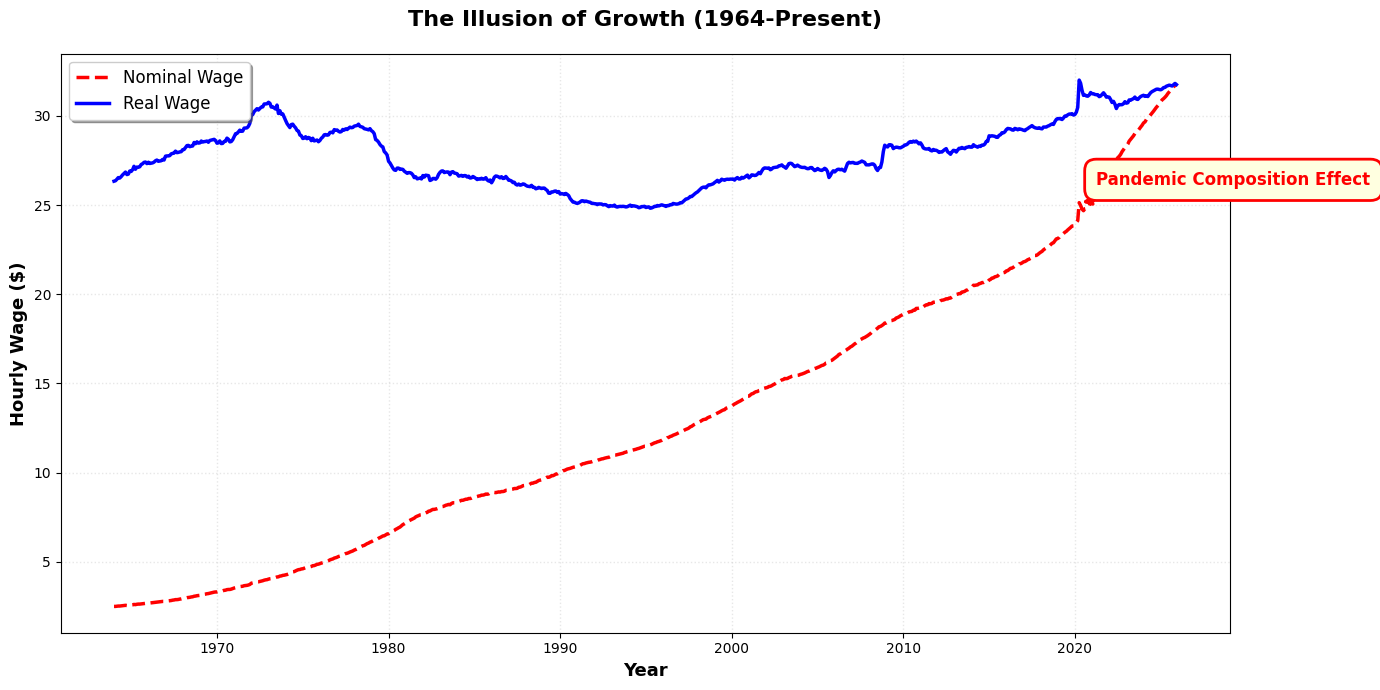


=== Wage Growth Analysis ===

Nominal Wage:
  Start: $2.50
  End: $31.76
  Total Growth: $29.26
  Percent Change: 1170.4%

Real Wage:
  Start: $26.34
  End: $31.76
  Total Growth: $5.42
  Percent Change: 20.6%

The Illusion: Nominal wages grew, but real purchasing power tells a different


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Create the large chart (14, 7)
plt.figure(figsize=(14, 7))

# 1. Plot Nominal_Wage as dashed red line
plt.plot(df.index, df['Nominal_Wage'],
         color='red', linestyle='--', linewidth=2.5,
         label='Nominal Wage')

# 2. Plot Real_Wage as solid blue line
plt.plot(df.index, df['Real_Wage'],
         color='blue', linestyle='-', linewidth=2.5,
         label='Real Wage')

# 3. Add title
plt.title('The Illusion of Growth (1964-Present)',
          fontsize=16, fontweight='bold', pad=20)

# 4. Annotate the 2020 spike
spike_date = pd.Timestamp('2020-04-01')

# Find the closest date in the index if exact date doesn't exist
if spike_date not in df.index:
    # Find the nearest date to 2020-04-01
    idx = (df.index - spike_date).abs().argmin()
    spike_date = df.index[idx]

# Get the nominal wage value at the spike
spike_value = df.loc[spike_date, 'Nominal_Wage']

# Add annotation
plt.annotate('Pandemic Composition Effect',
             xy=(spike_date, spike_value),
             xytext=(spike_date + pd.DateOffset(years=1), spike_value + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
             fontsize=12, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.7', facecolor='lightyellow',
                      edgecolor='red', linewidth=2))

# Additional formatting
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Hourly Wage ($)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

# Print key insights
print("\n=== Wage Growth Analysis ===")
print(f"\nNominal Wage:")
print(f"  Start: ${df['Nominal_Wage'].iloc[0]:.2f}")
print(f"  End: ${df['Nominal_Wage'].iloc[-1]:.2f}")
print(f"  Total Growth: ${df['Nominal_Wage'].iloc[-1] - df['Nominal_Wage'].iloc[0]:.2f}")
print(f"  Percent Change: {((df['Nominal_Wage'].iloc[-1] / df['Nominal_Wage'].iloc[0]) - 1) * 100:.1f}%")

print(f"\nReal Wage:")
print(f"  Start: ${df['Real_Wage'].iloc[0]:.2f}")
print(f"  End: ${df['Real_Wage'].iloc[-1]:.2f}")
print(f"  Total Growth: ${df['Real_Wage'].iloc[-1] - df['Real_Wage'].iloc[0]:.2f}")
print(f"  Percent Change: {((df['Real_Wage'].iloc[-1] / df['Real_Wage'].iloc[0]) - 1) * 100:.1f}%")

print(f"\nThe Illusion: Nominal wages grew, but real purchasing power tells a different")

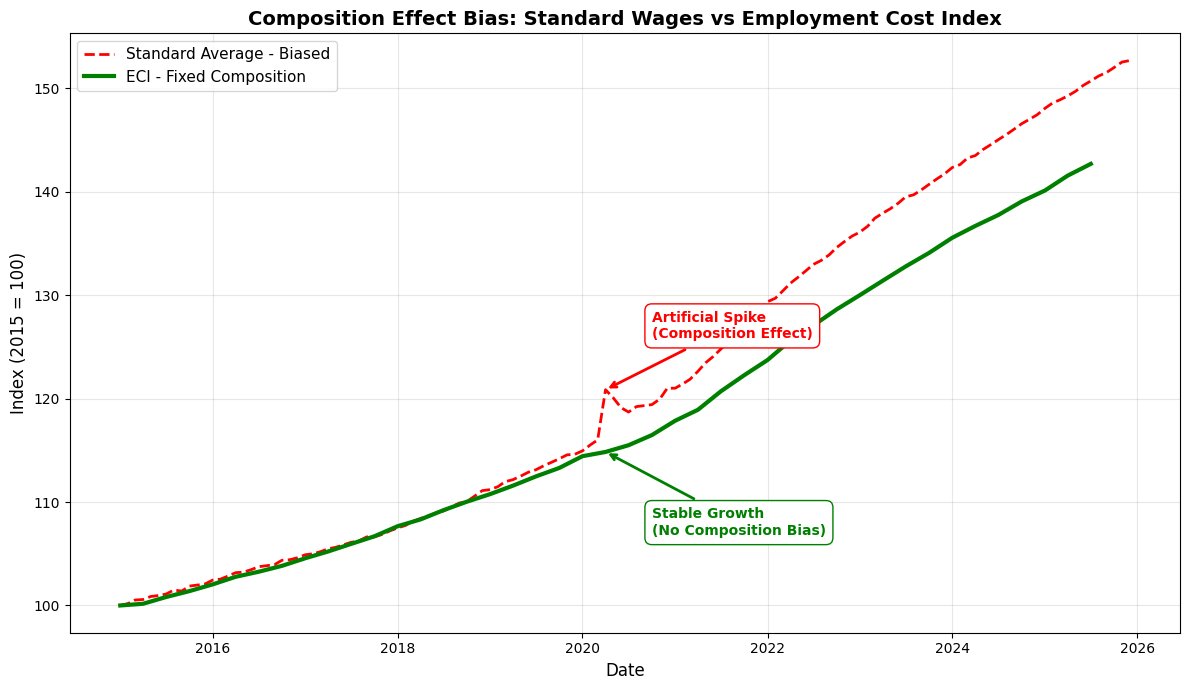


=== Summary Statistics ===

Standard Wages (Rebased):
  Start: 100.00
  End: 152.69
  Total Growth: 52.69 points

Employment Cost Index (Rebased):
  Start: 100.00
  End: 142.70
  Total Growth: 42.70 points

Divergence (Bias): 9.99 points


In [15]:
# 1. Fetch the Employment Cost Index (ECI) data
eci = fred.get_series('ECIWAG')

# 2. Filter both series to 2015-01-01 onwards
start_date = '2015-01-01'
wages_filtered = wages[wages.index >= start_date]
eci_filtered = eci[eci.index >= start_date]

# 3. Rebase both series to 100 (first value = 100)
wages_rebased = (wages_filtered / wages_filtered.iloc[0]) * 100
eci_rebased = (eci_filtered / eci_filtered.iloc[0]) * 100

# 4. Create the comparison plot
plt.figure(figsize=(12, 7))

# Plot wages as red dashed line
plt.plot(wages_rebased.index, wages_rebased,
         color='red', linestyle='--', linewidth=2,
         label='Standard Average - Biased')

# Plot ECI as green thick line
plt.plot(eci_rebased.index, eci_rebased,
         color='green', linewidth=3,
         label='ECI - Fixed Composition')

# 5. Add annotations for 2020 divergence
# Find approximate 2020 values for annotation
spike_date = pd.Timestamp('2020-04-01')
if spike_date in wages_rebased.index:
    spike_y = wages_rebased.loc[spike_date]
    plt.annotate('Artificial Spike\n(Composition Effect)',
                xy=(spike_date, spike_y),
                xytext=(spike_date + pd.DateOffset(months=6), spike_y + 5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, color='red', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red'))

stable_date = pd.Timestamp('2020-04-01')
if stable_date in eci_rebased.index:
    stable_y = eci_rebased.loc[stable_date]
    plt.annotate('Stable Growth\n(No Composition Bias)',
                xy=(stable_date, stable_y),
                xytext=(stable_date + pd.DateOffset(months=6), stable_y - 8),
                arrowprops=dict(arrowstyle='->', color='green', lw=2),
                fontsize=10, color='green', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='green'))

# Formatting
plt.title('Composition Effect Bias: Standard Wages vs Employment Cost Index',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index (2015 = 100)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"\nStandard Wages (Rebased):")
print(f"  Start: {wages_rebased.iloc[0]:.2f}")
print(f"  End: {wages_rebased.iloc[-1]:.2f}")
print(f"  Total Growth: {wages_rebased.iloc[-1] - wages_rebased.iloc[0]:.2f} points")

print(f"\nEmployment Cost Index (Rebased):")
print(f"  Start: {eci_rebased.iloc[0]:.2f}")
print(f"  End: {eci_rebased.iloc[-1]:.2f}")
print(f"  Total Growth: {eci_rebased.iloc[-1] - eci_rebased.iloc[0]:.2f} points")

print(f"\nDivergence (Bias): {(wages_rebased.iloc[-1] - eci_rebased.iloc[-1]):.2f} points")